# Notebook for finding the parameters where recall is 1 and runtime is good

In [300]:
import os
import sys
import itertools


def find_project_root(target_folder="masteroppgave"):
    """Find the absolute path of a folder by searching upward."""
    currentdir = os.path.abspath("__file__")  # Get absolute script path
    while True:
        if os.path.basename(currentdir) == target_folder:
            return currentdir  # Found the target folder
        parentdir = os.path.dirname(currentdir)
        if parentdir == currentdir:  # Stop at filesystem root
            return None
        currentdir = parentdir  # Move one level up

# Example usage
project_root = find_project_root("masteroppgave")

if project_root:
    sys.path.append(project_root)
    print(f"Project root found: {project_root}")
else:
    raise RuntimeError("Could not find 'masteroppgave' directory")

from utils.helpers.measure_similarities import *

Project root found: c:\Users\eivin\dev\masteroppgave


In [301]:
CITY = "rome"
MEASURE = "dtw"
DATA_SIZE = 500
SCHEME = "grid"
BUCKETING_METHOD = "loose"

## Read Bucketing Runtime CSV

In [302]:

folder_path = f"../../results_hashed/runtimes/bucketing/{CITY}/true_trajectories/{BUCKETING_METHOD}/{MEASURE}/"
file_name = f"runtimes_bucketing({BUCKETING_METHOD})_(true_trajectories)_{CITY}_{MEASURE}_{DATA_SIZE}_{SCHEME}.csv"
file_path = folder_path + file_name

runtime_bucketing = pd.read_csv(file_path, index_col=0)
runtime_bucketing.head()



runtime_bucketing.head(5)

,Measure,Resolution,Layers,Size,Average Similarity Computation Time (Seconds),Average Hash Generation Time (Seconds),Average Bucket Distribution Time (Seconds),Total time (Seconds)
City,,,,,,,,
rome,dtw,0.01,1,500,15.863,11.767,0.053,27.683
rome,dtw,0.01,2,500,19.932,10.054,0.112,30.098
rome,dtw,0.01,3,500,23.044,14.844,0.315,38.203
rome,dtw,0.01,4,500,24.956,20.115,0.231,45.302
rome,dtw,0.02,1,500,26.708,2.534,0.043,29.285


## Read No Bucketing Runtime CSV

In [303]:
DATA_SIZE_WITH_BRACKETS = f"[{DATA_SIZE}]"
folder_path = f"../../results_hashed/runtimes/no_bucketing/{CITY}/{MEASURE}/"
file_name = f"runtimes_{CITY}_{MEASURE}_{DATA_SIZE_WITH_BRACKETS}_{SCHEME}_no_bucketing.csv"
file_path = folder_path + file_name

runtime_no_bucketing = pd.read_csv(file_path)
runtime_no_bucketing.head(5)


,City,Measure,Resolution,Layers,Size,Average Similarity Computation Time (Seconds),Average Hash Generation Time (Seconds),Total time (Seconds)
0,rome,dtw,0.1,1,500,13.710,8.073,21.783
1,rome,dtw,0.1,2,500,27.579,1.141,28.720
2,rome,dtw,0.1,3,500,41.746,1.586,43.332
3,rome,dtw,0.1,4,500,55.113,2.209,57.322
4,rome,dtw,0.1,5,500,68.610,2.722,71.332


## Read No Bucketing Correlation

In [304]:

folder_path = f"../correlation/no_bucketing_correlation_values/"
file_name = f"correlation_results_{CITY}_grid_no_bucketing.csv"
file_path = folder_path + file_name

correlation_no_bucketing = pd.read_csv(file_path, index_col=0)
correlation_no_bucketing.head(5)

#Merge runtime_no_bucketing and correlation_no_bucketing on columns "Resolution" and "Layers"
runtime_no_bucketing = pd.merge(runtime_no_bucketing, correlation_no_bucketing, on=["Resolution", "Layers"])
runtime_no_bucketing.head(5)


,City,Measure,Resolution,Layers,Size,Average Similarity Computation Time (Seconds),Average Hash Generation Time (Seconds),Total time (Seconds),Correlation
0,rome,dtw,0.1,1,500,13.710,8.073,21.783,0.657
1,rome,dtw,0.1,2,500,27.579,1.141,28.720,0.662
2,rome,dtw,0.1,3,500,41.746,1.586,43.332,0.662
3,rome,dtw,0.1,4,500,55.113,2.209,57.322,0.664
4,rome,dtw,0.1,5,500,68.610,2.722,71.332,0.666


## Read Bucket Evaluation CSV

In [305]:
folder_path = f"../../results_hashed/bucket_evaluation/{BUCKETING_METHOD}/"
file_name = f"{CITY}_{MEASURE}_{SCHEME}_{DATA_SIZE}_{BUCKETING_METHOD}.csv"
file_path = folder_path + file_name

bucket_evaluation = pd.read_csv(file_path, index_col=0)

bucket_evaluation.head(5)

,Measure,Resolution,Layers,Size,Threshold,Avg Precision,Avg Recall,Avg F1 Score,Avg Number of buckets,Avg Bucket size,Avg Buckets with >1 Trajectory,Avg Largest Bucket Size,Avg Correlation Coefficient
City,,,,,,,,,,,,,
rome,dtw,0.01,1,500,0.1,0.003,0.889,0.007,16169.458,1.598,4834.042,16.333,0.798
rome,dtw,0.01,1,500,0.2,0.021,0.811,0.040,16169.458,1.598,4834.042,16.333,0.798
rome,dtw,0.01,1,500,0.3,0.054,0.713,0.100,16169.458,1.598,4834.042,16.333,0.798
rome,dtw,0.01,1,500,0.4,0.097,0.637,0.168,16169.458,1.598,4834.042,16.333,0.798
rome,dtw,0.01,1,500,0.5,0.145,0.558,0.230,16169.458,1.598,4834.042,16.333,0.798


In [306]:
# First, filter the bucket_evaluation dataframe
filtered_eval = bucket_evaluation[
    (bucket_evaluation["Avg Recall"] == 1) &
    (bucket_evaluation["Threshold"] == 0.1)
]

# Select only the necessary columns from runtime_bucketing
runtime_selected = runtime_bucketing[[
    "Resolution", "Layers",
    "Average Similarity Computation Time (Seconds)",
    "Average Hash Generation Time (Seconds)",
    "Average Bucket Distribution Time (Seconds)",
    "Total time (Seconds)"
]]

# Merge using only Diameter, Layers, and Disks as keys
runtime_bucketing_and_bucket_evaluation = filtered_eval.merge(
    runtime_selected,
    on=["Resolution", "Layers"],
    how="left"
)

columns_to_show = [
    "Resolution", "Layers",
    "Avg Correlation Coefficient",
    "Avg Recall", "Threshold",
    "Average Similarity Computation Time (Seconds)",
    "Average Hash Generation Time (Seconds)",
    "Average Bucket Distribution Time (Seconds)",
    "Total time (Seconds)"
]

runtime_bucketing_and_bucket_evaluation.head(5)



,Measure,Resolution,Layers,Size,Threshold,Avg Precision,Avg Recall,Avg F1 Score,Avg Number of buckets,Avg Bucket size,Avg Buckets with >1 Trajectory,Avg Largest Bucket Size,Avg Correlation Coefficient,Average Similarity Computation Time (Seconds),Average Hash Generation Time (Seconds),Average Bucket Distribution Time (Seconds),Total time (Seconds)
0,dtw,0.02,3,500,0.1,0.002,1.0,0.003,30568.708,2.338,13651.125,32.875,0.729,33.476,7.601,0.148,41.225
1,dtw,0.02,4,500,0.1,0.002,1.0,0.003,40750.167,2.339,18235.208,33.750,0.729,35.130,9.984,0.203,45.317
2,dtw,0.03,1,500,0.1,0.002,1.0,0.003,7408.958,3.041,3915.750,48.167,0.685,32.021,1.698,0.195,33.914
3,dtw,0.03,2,500,0.1,0.001,1.0,0.003,14819.875,3.039,7845.833,49.833,0.686,36.838,3.390,0.086,40.314
4,dtw,0.03,3,500,0.1,0.001,1.0,0.003,22221.667,3.040,11760.667,50.167,0.685,38.256,5.159,0.140,43.555


In [307]:
# Sort the merged dataframe by Avg Correlation Coefficient in descending order
runtime_bucketing_and_bucket_evaluation_sorted = runtime_bucketing_and_bucket_evaluation.sort_values(
    by="Total time (Seconds)",
    ascending=True
)
runtime_bucketing_and_bucket_evaluation_sorted.head(10)

#show only these columns
columns_to_show = [
    "Resolution", "Layers",
    "Avg Correlation Coefficient",
    "Avg Recall", "Threshold",
    "Average Similarity Computation Time (Seconds)",
    "Average Hash Generation Time (Seconds)",
    "Average Bucket Distribution Time (Seconds)",
    "Total time (Seconds)"
]
runtime_bucketing_and_bucket_evaluation_sorted = runtime_bucketing_and_bucket_evaluation_sorted[columns_to_show]

#extract lowest runtime Total time (Seconds) in the runtime_bucketing_and_bucket_evaluation_sorted dataframe
lowest_runtime = runtime_bucketing_and_bucket_evaluation_sorted.iloc[0]

lowest_runtime = runtime_bucketing_and_bucket_evaluation_sorted["Total time (Seconds)"].min()


print(lowest_runtime)


runtime_bucketing_and_bucket_evaluation_sorted.head(5)



33.914


,Resolution,Layers,Avg Correlation Coefficient,Avg Recall,Threshold,Average Similarity Computation Time (Seconds),Average Hash Generation Time (Seconds),Average Bucket Distribution Time (Seconds),Total time (Seconds)
2,0.03,1,0.685,1.0,0.1,32.021,1.698,0.195,33.914
6,0.04,1,0.651,1.0,0.1,36.015,1.436,0.035,37.486
10,0.05,1,0.626,1.0,0.1,37.861,1.074,0.032,38.967
3,0.03,2,0.686,1.0,0.1,36.838,3.390,0.086,40.314
14,0.06,1,0.603,1.0,0.1,39.955,0.917,0.033,40.905


In [308]:
runtime_no_bucketing.head(5)


# Merge runtime_no_bucketing with merged_df_sorted top 5 rows
runtime_no_bucketing_vs_runtime_bucketing = runtime_bucketing_and_bucket_evaluation_sorted.head(5)
runtime_no_bucketing_vs_runtime_bucketing = runtime_no_bucketing_vs_runtime_bucketing.merge(
    runtime_no_bucketing,
    on=["Resolution", "Layers"],
    how="left",
    suffixes=("", "_no_bucketing")
)
# Rename the columns to avoid confusion
runtime_no_bucketing_vs_runtime_bucketing.rename(
    columns={
        "Average Similarity Computation Time (Seconds)": "Average Similarity Computation Time (Seconds)_bucketing",
        "Average Hash Generation Time (Seconds)": "Average Hash Generation Time (Seconds)_bucketing",
        "Average Bucket Distribution Time (Seconds)": "Average Bucket Distribution Time (Seconds)_bucketing",
        "Total time (Seconds)": "Total time (Seconds)_bucketing"
    },
    inplace=True
)




runtime_no_bucketing_vs_runtime_bucketing.head()


,Resolution,Layers,Avg Correlation Coefficient,Avg Recall,Threshold,Average Similarity Computation Time (Seconds)_bucketing,Average Hash Generation Time (Seconds)_bucketing,Average Bucket Distribution Time (Seconds)_bucketing,Total time (Seconds)_bucketing,City,Measure,Size,Average Similarity Computation Time (Seconds)_no_bucketing,Average Hash Generation Time (Seconds)_no_bucketing,Total time (Seconds)_no_bucketing,Correlation
0,0.03,1,0.685,1.0,0.1,32.021,1.698,0.195,33.914,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.04,1,0.651,1.0,0.1,36.015,1.436,0.035,37.486,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.05,1,0.626,1.0,0.1,37.861,1.074,0.032,38.967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.03,2,0.686,1.0,0.1,36.838,3.390,0.086,40.314,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.06,1,0.603,1.0,0.1,39.955,0.917,0.033,40.905,NaN,NaN,NaN,NaN,NaN,NaN,NaN


     Resolution  Correlation
2           0.1        0.662
8           0.2        0.617
14          0.3        0.597
20          0.4        0.588
26          0.5        0.593
32          0.6        0.581
38          0.7        0.575
44          0.8        0.572
50          0.9        0.552
56          1.0        0.566
62          1.1        0.551
68          1.2        0.531
74          1.3        0.515
80          1.4        0.477
86          1.5        0.456
92          1.6        0.469
98          1.7        0.484
104         1.8        0.493
110         1.9        0.340
116         2.0        0.347
122         2.1        0.393
128         2.2        0.365
134         2.3        0.384
140         2.4        0.392
146         2.5        0.239
152         2.6        0.249
158         2.7        0.263
164         2.8        0.179
170         2.9        0.176
176         3.0        0.178


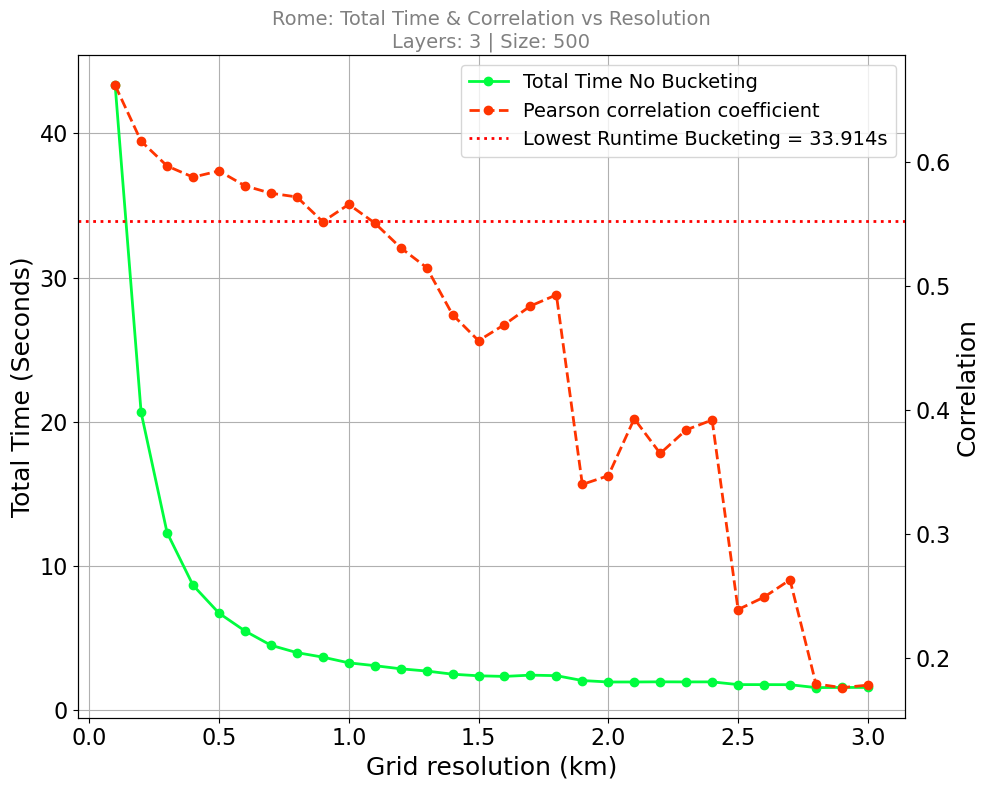

In [309]:
# Filter the runtime_no_bucketing dataframe to only include the rows where Layers = 3
filtered_runtime_no_bucketing = runtime_no_bucketing[runtime_no_bucketing["Layers"] == 3]

print(filtered_runtime_no_bucketing[["Resolution", "Correlation"]])


import matplotlib.pyplot as plt
import numpy as np

def plot_total_time_vs_resolution(
    df,
    city: str,
    measure: str = "dtw",
    layers: int = 3,
    size: int = 500,
    lowest_runtime: float = None,  # Add this argument
):
    """
    Plots the relationship between grid resolution and total time (in seconds),
    and overlays correlation on a secondary y-axis with clear labels.
    Adds a horizontal line for the externally provided lowest total runtime.
    """

    # Filter the DataFrame
    filtered = df[
        (df['City'] == city) &
        (df['Measure'] == measure) &
        (df['Layers'] == layers) &
        (df['Size'] == size)
    ].sort_values(by='Resolution')

    # Extract values
    res = filtered['Resolution'].values
    total_time = filtered['Total time (Seconds)'].values
    corr = filtered['Correlation'].astype(float).values

    # Plot
    fig, ax1 = plt.subplots(figsize=(10, 8), dpi=100)
    ax2 = ax1.twinx()
    cmap = plt.get_cmap("gist_ncar")

    line1 = ax1.plot(res, total_time, color=cmap(0.3), marker='o', lw=2, label='Total Time No Bucketing')[0]
    line2 = ax2.plot(res, corr, color=cmap(0.7), marker='o', lw=2, linestyle='--', label='Pearson correlation coefficient')[0]

    # Use provided lowest_runtime if available
    if lowest_runtime is not None:
        line3 = ax1.axhline(
            y=lowest_runtime,
            color='red',
            linestyle=':',
            linewidth=2,
            label=f'Lowest Runtime Bucketing = {lowest_runtime:.3f}s'
        )
        lines = [line1, line2, line3]
    else:
        lines = [line1, line2]

    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="upper right", fontsize=14)

    # Axis labels and styling
    ax1.set_xlabel("Grid resolution (km)", fontsize=18)
    ax1.set_ylabel("Total Time (Seconds)", fontsize=18)
    ax2.set_ylabel("Correlation", fontsize=18)
    

    ax1.tick_params(axis="both", which="major", labelsize=16)
    ax2.tick_params(axis="both", which="major", labelsize=16)

    ax1.set_title(
        f"{city.capitalize()}: Total Time & Correlation vs Resolution\nLayers: {layers} | Size: {size}",
        fontsize=14,
        color='grey'
    )

    ax1.grid(True)
    fig.tight_layout()
    plt.show()




plot_total_time_vs_resolution(
    filtered_runtime_no_bucketing,
    city=CITY,
    measure="dtw",
    layers=3,
    size=500,
    lowest_runtime=lowest_runtime  # Pass the value from your earlier cell
)


# filtered_runtime_no_bucketing.head(5)
